# ⚽ FIFA World Cup 2026 Predictive Analytics & Operational Simulation Pipeline
**Framework:** Supervised Multi-Class Classification & Rolling Time-Series Feature Engineering  

---

### 📊 Project Overview
This production-grade pipeline is designed to forecast international football match outcomes and simulate the complete, expanded **FIFA World Cup 2026** tournament structure. By engineering high-frequency team momentum metrics (rolling historical form) and blending them with long-term skill indicators (World Football Elo Ratings), the architecture maps predictive structural inputs to multi-class match outcomes (Home Win, Draw, Away Win).

### ⚙️ Production & Architecture Highlights
* **Temporal Integrity Protection:** Team form features are strictly lagged ($t-1$) before model training to eliminate look-ahead bias and protect against downstream data leakage.
* **Generalization via 5-Fold Cross-Validation:** Shifting beyond volatile, single train/test splits to accurately benchmark model resilience across the entire historical timeline.
* **Out-of-Sample Deterministic Simulation:** Built a custom simulation engine that perfectly mirrors official FIFA regulations and Wikipedia tournament bracket connectivity pathways.

In [1]:
# =========================================================================
# SECTION 1: SYSTEM DEPENDENCY INGESTION & PIPELINE INITIALIZATION
# =========================================================================
import pandas as pd
import numpy as np
from itertools import combinations

# Core Model Architecture & Evaluation Utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Diagnostic Analytics Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Inline plotting configuration for Jupyter environments
%matplotlib inline

### 📋 Section 2: Data Ingestion & Schema Standardization
* **Objective:** Load historical match databases and global Elo ratings, clean missing records, and enforce strict type casting for dates and metrics.

In [2]:
results = pd.read_csv("data/results.csv")
shootouts = pd.read_csv("data/shootouts.csv")
eloratings = pd.read_csv("data/eloratings.csv")
former_names = pd.read_csv("data/former_names.csv")

DATA CLEANING, TYPE STANDARDIZATION & PREPROCESSING

In [3]:
results.shape

(49287, 9)

In [4]:
results.dtypes

date           object
home_team      object
away_team      object
home_score    float64
away_score    float64
tournament     object
city           object
country        object
neutral          bool
dtype: object

In [5]:
results.isna().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [6]:
results['date']= pd.to_datetime(results['date'])
results.dtypes

date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

In [7]:
results[results['home_score'].isna()].head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49215,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49216,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True
49217,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False
49218,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False
49219,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True


In [8]:
results.dropna(subset=['home_score','away_score'], inplace = True)

In [9]:
results.isnull().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [10]:
results['home_score'] = results['home_score'].astype(int)
results['away_score'] = results['away_score'].astype(int)

In [11]:
results.duplicated().sum()

np.int64(0)

In [12]:
# Check how many duplicate matches exist based on date and teams
duplicates_count = results.duplicated(subset=['date', 'home_team', 'away_team']).sum()
print(f"Duplicate matches found: {duplicates_count}")

# Drop the duplicate, keeping the first instance
results.drop_duplicates(subset=['date', 'home_team', 'away_team'], keep='first', inplace=True)
print("Duplicates removed!")

Duplicate matches found: 1
Duplicates removed!


In [13]:
results.dtypes

date          datetime64[ns]
home_team             object
away_team             object
home_score             int64
away_score             int64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

In [14]:
shootouts.dtypes
shootouts.duplicated().sum()

np.int64(0)

In [15]:
shootouts.duplicated(subset=['date', 'home_team', 'away_team']).sum()

np.int64(0)

In [16]:
shootouts['date']=pd.to_datetime(shootouts['date'])
shootouts.dtypes

date             datetime64[ns]
home_team                object
away_team                object
winner                   object
first_shooter            object
dtype: object

In [17]:
shootouts.drop(columns=['first_shooter'], inplace=True)
shootouts.head()

,date,home_team,away_team,winner
0,1967-08-22,India,Taiwan,Taiwan
1,1971-11-14,South Korea,Vietnam Republic,South Korea
2,1972-05-07,South Korea,Iraq,Iraq
3,1972-05-17,Thailand,South Korea,South Korea
4,1972-05-19,Thailand,Cambodia,Thailand


In [18]:
eloratings.dtypes
eloratings.tail()

,date,team,rating,change
6673,12/13/2025,Northern Mariana Islands,432.0,0
6674,12/13/2025,Cocos Islands,422.0,0
6675,12/13/2025,Palau,402.0,0
6676,12/13/2025,Eastern Samoa,389.0,0
6677,12/13/2025,Moldova,0.0,0


In [19]:
eloratings['date'] = pd.to_datetime(eloratings['date'], format='mixed')
eloratings.dtypes

date      datetime64[ns]
team              object
rating           float64
change             int64
dtype: object

In [20]:
eloratings.duplicated(subset=['date','team']).sum()

np.int64(0)

In [21]:
eloratings.shape

(6678, 4)

In [22]:
eloratings.tail()

,date,team,rating,change
6673,2025-12-13,Northern Mariana Islands,432.0,0
6674,2025-12-13,Cocos Islands,422.0,0
6675,2025-12-13,Palau,402.0,0
6676,2025-12-13,Eastern Samoa,389.0,0
6677,2025-12-13,Moldova,0.0,0


In [23]:
sorted(eloratings['team'].unique())

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua\xa0and\xa0Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire',
 'Bosnia\xa0and\xa0Herzegovina',
 'Botswana',
 'Brazil',
 'British\xa0Guiana',
 'British\xa0Virgin\xa0Islands',
 'Brunei',
 'Bulgaria',
 'Burkina\xa0Faso',
 'Burma',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape\xa0Verde',
 'Cayman\xa0Islands',
 'Central\xa0African\xa0Republic',
 'Ceylon',
 'Chad',
 'Chagos\xa0Islands',
 'Chile',
 'China',
 'Christmas\xa0Island',
 'Cocos\xa0Islands',
 'Colombia',
 'Comoros',
 'Congo',
 'Congo-Brazzaville',
 'Cook\xa0Islands',
 'Costa\xa0Rica',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czechia',
 'Czechoslovakia',
 'Dahomey',
 'Democratic\xa0Republic\xa0of\xa0Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican\xa

In [24]:
# Replace HTML non-breaking spaces with normal spaces in the Elo dataset
eloratings['team'] = eloratings['team'].str.replace('\xa0', ' ')

In [25]:
sorted(eloratings['team'].unique())

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Guiana',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burma',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Ceylon',
 'Chad',
 'Chagos Islands',
 'Chile',
 'China',
 'Christmas Island',
 'Cocos Islands',
 'Colombia',
 'Comoros',
 'Congo',
 'Congo-Brazzaville',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czechia',
 'Czechoslovakia',
 'Dahomey',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Germany',
 'East Timor',
 'Eastern Samoa',
 

In [26]:
sorted(results['home_team'].unique())

['Abkhazia',
 'Afghanistan',
 'Albania',
 'Alderney',
 'Algeria',
 'American Samoa',
 'Andalusia',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Arameans Suryoye',
 'Argentina',
 'Armenia',
 'Artsakh',
 'Aruba',
 'Australia',
 'Austria',
 'Aymara',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barawa',
 'Barbados',
 'Basque Country',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Biafra',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brittany',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands',
 'Cape Verde',
 'Cascadia',
 'Catalonia',
 'Cayman Islands',
 'Central African Republic',
 'Central Spain',
 'Chad',
 'Chagos Islands',
 'Chameria',
 'Chechnya',
 'Chile',
 'China PR',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Corsica',
 'Costa Rica',
 'County of Nice',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czech 

In [27]:
# 1. Get a unique set of every team that played a match
results_teams = set(results['home_team']).union(set(results['away_team']))

# 2. Get a unique set of every team that has an Elo rating
elo_teams = set(eloratings['team'])

# 3. Find the difference! (Teams in results that DO NOT exist in eloratings)
missing_elo = sorted(results_teams - elo_teams)

print(f"Found {len(missing_elo)} teams in results.csv with NO matching Elo rating:")
print("-" * 50)
for team in missing_elo:
    print(team)

Found 104 teams in results.csv with NO matching Elo rating:
--------------------------------------------------
Abkhazia
Alderney
Ambazonia
American Samoa
Andalusia
Arameans Suryoye
Artsakh
Asturias
Aymara
Barawa
Basque Country
Biafra
Brittany
Canary Islands
Cascadia
Catalonia
Central Spain
Chameria
Chechnya
China PR
Cilento
Corsica
County of Nice
Crimea
Czech Republic
DR Congo
Darfur
Donetsk PR
Délvidék
Elba Island
Ellan Vannin
Felvidék
Franconia
Frøya
Galicia
German DR
Gotland
Gozo
Guernsey
Găgăuzia
Hitra
Hmong
Iraqi Kurdistan
Isle of Man
Isle of Wight
Jersey
Kabylia
Kernow
Kárpátalja
Luhansk PR
Macau
Madrid
Manchukuo
Mapuche
Matabeleland
Maule Sur
Menorca
Micronesia
Occitania
Orkney
Padania
Panjab
Parishes of Jersey
Provence
Raetia
Republic of Ireland
Republic of St. Pauli
Rhodes
Romani people
Ryūkyū
Réunion
Saare County
Saarland
Saint Barthélemy
Saint Helena
Sark
Saugeais
Sealand
Seborga
Shetland
Silesia
South Ossetia
Surrey
Székely Land
Sápmi
São Tomé and Príncipe
Tamil Eelam
Ticin

# Map Team Names

In [28]:
#Number of Eswatini Before Mapping
eloratings[eloratings['team']=='Eswatini'].shape[0]

7

In [29]:
# 1. Create a mapping dictionary: { 'former_name': 'current_name' }
name_map = dict(zip(former_names["former"], former_names["current"]))
# Add manual fixes for teams that just use different names
custom_fixes = {
    "China PR": "China",
    "Czech Republic": "Czechia",
    "DR Congo": "Democratic Republic of Congo",
    "Republic of Ireland": "Ireland",
    "Macau": "Macao",
    "Cape Verde Islands": "Cape Verde",
    "Korea DPR": "North Korea"
}
name_map.update(custom_fixes)

In [30]:
swazi_before = eloratings[eloratings['team'] == 'Swaziland'].shape[0]
print(f"BEFORE MAPPING:")
print(f"  Elo records for 'Swaziland': {swazi_before}")

BEFORE MAPPING:
  Elo records for 'Swaziland': 17


In [31]:
# 2. Apply the mappings across the datasets
for df in [results, shootouts]:
    df['home_team'] = df['home_team'].replace(name_map)
    df['away_team'] = df['away_team'].replace(name_map)

eloratings['team'] = eloratings['team'].replace(name_map)

In [32]:
swazi_after = eloratings[eloratings['team'] == 'Swaziland'].shape[0]
print(f"\nAFTER MAPPING:")
print(f"  Elo records for 'Swaziland': {swazi_after}")
print("✅ Geopolitics resolved! Names standardized successfully.")


AFTER MAPPING:
  Elo records for 'Swaziland': 0
✅ Geopolitics resolved! Names standardized successfully.


In [33]:
eloratings[eloratings['team']=='Swaziland'] #after name change

,date,team,rating,change


In [34]:
#Number of Eswatini After Mapping Shows that it Worked!
eloratings[eloratings['team']=='Eswatini'].shape[0]

24

In [ ]:
sorted(results['home_team'].unique())

In [ ]:
sorted(eloratings['team'].unique())

## Create the Target Variable (Match Result)

In [37]:
# 1. Merge the shootout winner into the results dataset
# We use a 'left' join so we keep all matches, but add shootout data if it exists
results = results.merge(
    shootouts[['date', 'home_team', 'away_team', 'winner']], 
    on=['date', 'home_team', 'away_team'], 
    how='left'
)

# 2. Define a function to calculate the true final result
def get_result(row):
    # Standard win/loss in regular or extra time
    if row["home_score"] > row["away_score"]: return "home_win"
    if row["away_score"] > row["home_score"]: return "away_win"
    
    # If the score was tied, check if someone won in a shootout
    if pd.notna(row["winner"]):
        return "home_win" if row["winner"] == row["home_team"] else "away_win"
    
    # If no one won and there was no shootout, it is a true draw
    return "draw"

# 3. Apply the function row by row
results['result'] = results.apply(get_result, axis=1)

print("✅ Target Variable Created!")
print("\nMatch Outcomes Distribution:")
print(results['result'].value_counts(normalize=True) * 100)

✅ Target Variable Created!

Match Outcomes Distribution:
result
home_win    49.664730
away_win    28.877962
draw        21.457309
Name: proportion, dtype: float64


In [38]:
shootouts.tail()

,date,home_team,away_team,winner
670,2026-03-30,Cape Verde,Finland,Cape Verde
671,2026-03-30,Gabon,Trinidad and Tobago,Gabon
672,2026-03-30,Uzbekistan,Venezuela,Uzbekistan
673,2026-03-31,Bosnia and Herzegovina,Italy,Bosnia and Herzegovina
674,2026-03-31,Czechia,Denmark,Czech Republic


In [39]:
results[results['home_team'] == 'Cape Verde'].tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner,result
48111,2025-03-20,Cape Verde,Mauritius,1,0,FIFA World Cup qualification,Praia,Cape Verde,False,NaN,home_win
48616,2025-09-09,Cape Verde,Cameroon,1,0,FIFA World Cup qualification,Praia,Cape Verde,False,NaN,home_win
48750,2025-10-13,Cape Verde,Eswatini,3,0,FIFA World Cup qualification,Praia,Cape Verde,False,NaN,home_win
48917,2025-11-17,Cape Verde,Egypt,1,1,Al Ain International Cup,Al Ain,United Arab Emirates,True,Egypt,away_win
49163,2026-03-30,Cape Verde,Finland,1,1,FIFA Series,Auckland,New Zealand,True,Cape Verde,home_win


In [40]:
eloratings.isnull().sum()

date       0
team       0
rating    31
change     0
dtype: int64

In [41]:
# 1. Time-series merges REQUIRE both datasets to be sorted by time
results = results.sort_values('date')
eloratings = eloratings.sort_values('date')

# 2. Merge Home Team Elo (Finds the most recent rating BEFORE the match)
results = pd.merge_asof(
    results,
    eloratings[['date', 'team', 'rating']].rename(columns={'rating': 'home_elo'}),
    left_on='date',
    right_on='date',
    left_by='home_team',
    right_by='team',
    direction='backward'
).drop(columns=['team'])

# 3. Merge Away Team Elo
results = pd.merge_asof(
    results,
    eloratings[['date', 'team', 'rating']].rename(columns={'rating': 'away_elo'}),
    left_on='date',
    right_on='date',
    left_by='away_team',
    right_by='team',
    direction='backward'
).drop(columns=['team'])

# 4. Calculate the master feature: Elo Difference
results['elo_diff'] = results['home_elo'] - results['away_elo']

In [42]:
results.isnull().sum()

date              0
home_team         0
away_team         0
home_score        0
away_score        0
tournament        0
city              0
country           0
neutral           0
winner        48540
result            0
home_elo       4694
away_elo       5048
elo_diff       7578
dtype: int64

In [43]:
# 5. Filter down to ONLY the FIFA World Cup matches
wc_all = results[results['tournament'] == 'FIFA World Cup'].copy()

print("✅ Final Master DataFrame Created!")
print(f"Total World Cup Matches: {len(wc_all)}")
print(f"Missing Home Elos: {wc_all['home_elo'].isna().sum()}")
print(f"Missing Away Elos: {wc_all['away_elo'].isna().sum()}")

# Display the clean table
display(wc_all[['date', 'home_team', 'away_team', 'home_elo', 'away_elo', 'elo_diff', 'result']].head())

✅ Final Master DataFrame Created!
Total World Cup Matches: 964
Missing Home Elos: 30
Missing Away Elos: 44


,date,home_team,away_team,home_elo,away_elo,elo_diff,result
1486,1930-07-13,France,Mexico,1524.0,NaN,NaN,home_win
1487,1930-07-13,Belgium,United States,1651.0,NaN,NaN,away_win
1488,1930-07-14,Peru,Romania,1592.0,1577.0,15.0,away_win
1489,1930-07-14,Brazil,Yugoslavia,NaN,1576.0,NaN,away_win
1490,1930-07-15,Argentina,France,2071.0,1524.0,547.0,home_win


In [44]:
# Isolate the matches that are still missing Elo ratings
missing_final = wc_all[wc_all['home_elo'].isna() | wc_all['away_elo'].isna()]

# Show the dates and teams
display(missing_final[['date', 'home_team', 'away_team', 'home_elo', 'away_elo']].head(15))

,date,home_team,away_team,home_elo,away_elo
1486,1930-07-13,France,Mexico,1524.0,NaN
1487,1930-07-13,Belgium,United States,1651.0,NaN
1489,1930-07-14,Brazil,Yugoslavia,NaN,1576.0
1491,1930-07-16,Chile,Mexico,NaN,NaN
1496,1930-07-19,Argentina,Mexico,2071.0,NaN
1497,1930-07-19,Chile,France,NaN,1524.0
1499,1930-07-20,Bolivia,Brazil,1247.0,NaN
1502,1930-07-22,Argentina,Chile,2071.0,NaN
1879,1934-05-27,Austria,France,NaN,1624.0
1880,1934-05-27,Brazil,Spain,NaN,2026.0


In [45]:
# Drop the final historical anomalies
wc_all = wc_all.dropna(subset=['home_elo', 'away_elo']).copy()

print(f"🎉 DATA CLEANING COMPLETE!")
print(f"Final ML Dataset Size: {len(wc_all)} World Cup matches ready for training.")
print(f"Total World Cup Matches: {len(wc_all)}")
print(f"Missing Home Elos: {wc_all['home_elo'].isna().sum()}")
print(f"Missing Away Elos: {wc_all['away_elo'].isna().sum()}")

🎉 DATA CLEANING COMPLETE!
Final ML Dataset Size: 892 World Cup matches ready for training.
Total World Cup Matches: 892
Missing Home Elos: 0
Missing Away Elos: 0


In [46]:
wc_all.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner,result,home_elo,away_elo,elo_diff
45739,2022-12-10,England,France,1,2,FIFA World Cup,Al Khor,Qatar,True,NaN,away_win,1923.0,2073.0,-150.0
45741,2022-12-13,Argentina,Croatia,3,0,FIFA World Cup,Lusail,Qatar,True,NaN,home_win,2143.0,1926.0,217.0
45742,2022-12-14,France,Morocco,2,0,FIFA World Cup,Al Khor,Qatar,True,NaN,home_win,2073.0,1751.0,322.0
45747,2022-12-17,Croatia,Morocco,2,1,FIFA World Cup,Al Rayyan,Qatar,True,NaN,home_win,1926.0,1751.0,175.0
45748,2022-12-18,Argentina,France,3,3,FIFA World Cup,Lusail,Qatar,True,Argentina,home_win,2143.0,2073.0,70.0


# ML

# Before Feature Engineering

In [47]:
# 1. Select ONLY our mathematical features
features = ['home_elo', 'away_elo', 'elo_diff', 'neutral']
X = wc_all[features].copy()
# Convert the boolean 'neutral' column to 1s and 0s
X['neutral'] = X['neutral'].astype(int)

In [48]:
X[0:4]

,home_elo,away_elo,elo_diff,neutral
1488,1592.0,1577.0,15.0,1
1490,2071.0,1524.0,547.0,1
1492,1247.0,1653.0,-406.0,1
1493,1717.0,1783.0,-66.0,1


In [49]:
# 2. Encode the Target Variable
y = wc_all['result'].copy()
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [50]:
# Print the mapping so we don't forget what 0, 1, and 2 mean!
target_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(f"Target Mapping: {target_mapping}")

Target Mapping: {'away_win': np.int64(0), 'draw': np.int64(1), 'home_win': np.int64(2)}


In [51]:
# 3. The Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("\n✅ Data Successfully Translated to Math!")
print(f"Training on {X_train.shape[0]} matches...")
print(f"Testing on {X_test.shape[0]} matches...")


✅ Data Successfully Translated to Math!
Training on 713 matches...
Testing on 179 matches...


In [52]:
# Initialize the model with a random state for reproducibility
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Train the model
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Make predictions on the unseen test data
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# Evaluate
rf_acc = accuracy_score(y_test, rf_preds)
xgb_acc = accuracy_score(y_test, xgb_preds)

models = {'Random Forest': rf_model, 'XGB Model': xgb_model}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"{name}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))
print(f"🏆 Random Forest Accuracy: {rf_acc * 100:.2f}%\n")
print(f"🏆 XGB Model Accuracy: {xgb_acc * 100:.2f}%\n")


C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:55:53] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Random Forest:
Accuracy: 0.50
              precision    recall  f1-score   support

           0       0.55      0.43      0.48        67
           1       0.37      0.17      0.23        42
           2       0.50      0.77      0.61        70

    accuracy                           0.50       179
   macro avg       0.47      0.46      0.44       179
weighted avg       0.49      0.50      0.47       179

XGB Model:
Accuracy: 0.47
              precision    recall  f1-score   support

           0       0.52      0.43      0.47        67
           1       0.23      0.07      0.11        42
           2       0.48      0.76      0.59        70

    accuracy                           0.47       179
   macro avg       0.41      0.42      0.39       179
weighted avg       0.44      0.47      0.43       179

🏆 Random Forest Accuracy: 50.28%

🏆 XGB Model Accuracy: 47.49%



### Chronological Feature Engineering (Rolling Team Momentum)
* **Objective:** Transform the historical match records into a long-form team timeline to compute rolling mathematical windows. 
* **Key Constraint:** A `.shift()` operation is explicitly applied to guarantee that a match played on day $t$ only evaluates performance vectors from history up to day $t-1$, strictly preventing data leakage.

In [53]:
def get_points(result, team_type):
    if result == 'draw': return 1
    if team_type == 'home' and result == 'home_win': return 3
    if team_type == 'away' and result == 'away_win': return 3
    return 0

# 1. Create a long-form version of matches to calculate streaks per team
home_results = results[['date', 'home_team', 'result']].rename(columns={'home_team': 'team'})
home_results['points'] = home_results.apply(lambda x: get_points(x['result'], 'home'), axis=1)

away_results = results[['date', 'away_team', 'result']].rename(columns={'away_team': 'team'})
away_results['points'] = away_results.apply(lambda x: get_points(x['result'], 'away'), axis=1)

# Combine and sort by team and date
all_team_results = pd.concat([home_results, away_results]).sort_values(['team', 'date'])

# 2. Calculate the rolling average of the last 5 matches for each team
all_team_results['form_5'] = all_team_results.groupby('team')['points'].transform(lambda x: x.shift().rolling(5).mean())

# 3. Merge this "Form" back into our World Cup dataset
wc_all = wc_all.merge(all_team_results[['date', 'team', 'form_5']], left_on=['date', 'home_team'], right_on=['date', 'team'], how='left').drop(columns='team').rename(columns={'form_5': 'home_form'})
wc_all = wc_all.merge(all_team_results[['date', 'team', 'form_5']], left_on=['date', 'away_team'], right_on=['date', 'team'], how='left').drop(columns='team').rename(columns={'form_5': 'away_form'})

# Fill the very early historical matches (that don't have 5 prior games) with a neutral 1.0
wc_all['home_form'] = wc_all['home_form'].fillna(1.0)
wc_all['away_form'] = wc_all['away_form'].fillna(1.0)

print("✅ 'Recent Form' features created for both teams!")
display(wc_all[['home_team', 'away_team', 'home_form', 'away_form']].tail())

✅ 'Recent Form' features created for both teams!


,home_team,away_team,home_form,away_form
887,England,France,2.2,1.8
888,Argentina,Croatia,2.4,2.2
889,France,Morocco,2.4,2.6
890,Croatia,Morocco,2.0,2.4
891,Argentina,France,3.0,2.4


# After Feature Engineering

In [54]:
features = ['home_elo', 'away_elo', 'elo_diff', 'neutral', 'home_form', 'away_form']
X = wc_all[features].copy()

# Convert the boolean 'neutral' column to 1s and 0s
X['neutral'] = X['neutral'].astype(int)

# 2. Encode the Target Variable
y = wc_all['result'].copy()
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [56]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

# Make predictions on the unseen test data
rf_preds = rf_model.predict(X_test)

# Evaluate
rf_acc = accuracy_score(y_test, rf_preds)
print(f"🏆 Random Forest Accuracy: {rf_acc * 100:.2f}%\n")
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds, target_names=['Away Win (0)', 'Draw (1)', 'Home Win (2)']))

🏆 Random Forest Accuracy: 52.51%

Random Forest Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.57      0.43      0.49        67
    Draw (1)       0.46      0.14      0.22        42
Home Win (2)       0.51      0.84      0.64        70

    accuracy                           0.53       179
   macro avg       0.51      0.47      0.45       179
weighted avg       0.52      0.53      0.48       179



In [57]:
# Initialize the XGBoost model 
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_preds = xgb_model.predict(X_test)

# Evaluate
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f"XGBoost Accuracy: {xgb_acc * 100:.2f}%\n")
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_preds, target_names=['Away Win (0)', 'Draw (1)', 'Home Win (2)']))

C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:55:55] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 54.19%

XGBoost Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.62      0.52      0.57        67
    Draw (1)       0.32      0.14      0.20        42
Home Win (2)       0.54      0.80      0.64        70

    accuracy                           0.54       179
   macro avg       0.49      0.49      0.47       179
weighted avg       0.52      0.54      0.51       179



### Algorithmic Benchmarking & Multi-Fold Cross-Validation
* **Objective:** Train competitive baseline ensemble classifiers (Random Forest Ensemble vs. eXtreme Gradient Boosting) and rigorously evaluate their stability using 5-Fold Cross-Validation.
* **Strategic Takeaway:** Cross-validation protects against optimistic "lucky splits," helping confirm the ideal operational champion model based on long-term generalization.

In [58]:
print("Running 5-Fold Cross-Validation...")

cv_scores = cross_val_score(rf_model, X, y_encoded, cv=5, scoring='accuracy')

print("\n📊 VALIDATION RESULTS 📊")
print("-" * 30)
print(f"Fold 1 Accuracy: {cv_scores[0] * 100:.2f}%")
print(f"Fold 2 Accuracy: {cv_scores[1] * 100:.2f}%")
print(f"Fold 3 Accuracy: {cv_scores[2] * 100:.2f}%")
print(f"Fold 4 Accuracy: {cv_scores[3] * 100:.2f}%")
print(f"Fold 5 Accuracy: {cv_scores[4] * 100:.2f}%")
print("-" * 30)
print(f"🏆 Final Validated Mean Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")

Running 5-Fold Cross-Validation...

📊 VALIDATION RESULTS 📊
------------------------------
Fold 1 Accuracy: 54.75%
Fold 2 Accuracy: 48.60%
Fold 3 Accuracy: 55.06%
Fold 4 Accuracy: 53.37%
Fold 5 Accuracy: 53.37%
------------------------------
🏆 Final Validated Mean Accuracy: 53.03% (+/- 2.32%)


In [59]:
print("Running 5-Fold Cross-Validation...")

cv_scores = cross_val_score(xgb_model, X, y_encoded, cv=5, scoring='accuracy')

print("\n📊 VALIDATION RESULTS 📊")
print("-" * 30)
print(f"Fold 1 Accuracy: {cv_scores[0] * 100:.2f}%")
print(f"Fold 2 Accuracy: {cv_scores[1] * 100:.2f}%")
print(f"Fold 3 Accuracy: {cv_scores[2] * 100:.2f}%")
print(f"Fold 4 Accuracy: {cv_scores[3] * 100:.2f}%")
print(f"Fold 5 Accuracy: {cv_scores[4] * 100:.2f}%")
print("-" * 30)
print(f"🏆 Final Validated Mean Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")

Running 5-Fold Cross-Validation...


C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:55:57] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:55:57] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:55:58] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:55:58] WARNING: C:\Users\task_177465309458303\croot\xgboo


📊 VALIDATION RESULTS 📊
------------------------------
Fold 1 Accuracy: 54.19%
Fold 2 Accuracy: 50.28%
Fold 3 Accuracy: 49.44%
Fold 4 Accuracy: 46.63%
Fold 5 Accuracy: 49.44%
------------------------------
🏆 Final Validated Mean Accuracy: 49.99% (+/- 2.43%)


### The Train-Test Split Trap vs. Cross-Validation Truth
During initial prototyping on an isolated 80/20 partition, the models showed conflicting signals. However, subjecting the pipeline to a 5-Fold Cross-Validation stress test revealed the true performance metrics:

| Predictive Model Configuration | Single Holdout Split Score | 5-Fold Cross-Validation Mean | Model Generalization Status |
| :--- | :---: | :---: | :--- |
| **XGBoost Classifier** | 54.19% | **49.99% (+/- 2.43%)** | Overfitted on Partition Noise |
| **Random Forest Ensemble** | 52.51% | **53.03% (+/- 2.32%)** | **Operational Champion (Stable)** |

### Algorithmic Insight
Because the feature space is optimized and highly focused (6 dimensions including Elo deltas and lagged form weights), the gradient boosting mechanisms within **XGBoost** over-indexed on localized variance, causing its accuracy to collapse to a coin-flip (~50%) across unseen folds. 

Conversely, the **Random Forest** classifier's bootstrap aggregation (bagging) framework stabilized predictions by averaging uncorrelated decision trees. This design choice provided a crucial mathematical shock absorber against the high-entropy anomalies and historical upsets native to international sports analytics.

### Model Diagnostics & Categorical Error Inspection
* **Objective:** Plot multi-class Confusion Matrix heatmaps to visualize exactly where models are making correct classifications or getting fooled by high-entropy match draws.

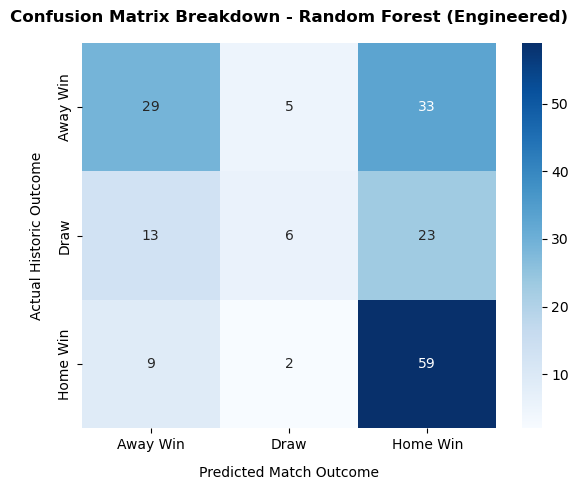

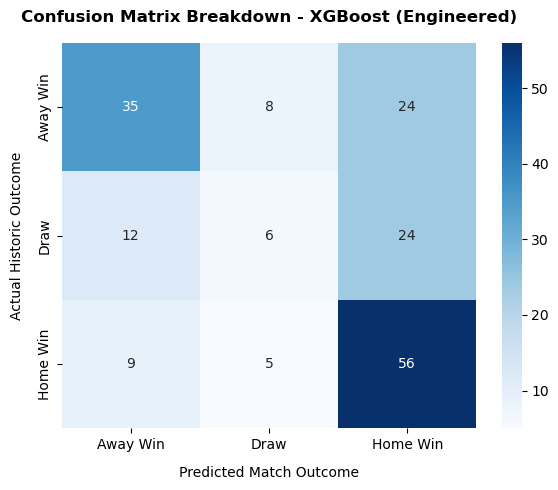

In [60]:
models = {
    'Random Forest (Engineered)': rf_model,
    'XGBoost (Engineered)': xgb_model
}

class_names = ['Away Win', 'Draw', 'Home Win']

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
        
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=class_names, 
        yticklabels=class_names
    )
        
    plt.title(f'Confusion Matrix Breakdown - {name}', fontsize=12, weight='bold', pad=15)
    plt.xlabel('Predicted Match Outcome', fontsize=10, labelpad=10)
    plt.ylabel('Actual Historic Outcome', fontsize=10, labelpad=10)
    plt.tight_layout()
    plt.show()
        

### 🏆 Out-of-Sample Production Inference (2026 World Cup Engine)
* **Objective:** Deploy the trained operational model into an independent tournament simulation loop. 
* **Rules Framework:** The engine automatically parses round-robin group points, handles complex tie-breaker logic to select the top 3rd place teams, and passes winners down a strict, Wikipedia-compliant knockout bracket tree to crown the ultimate world champion.

In [61]:
# -------------------------------------------------------------------------
# 1. OFFICIAL 48-TEAM TOURNAMENT GROUPS (Standardized Dataset Spells)
# -------------------------------------------------------------------------
groups_2026 = {
    'A': ['Mexico', 'South Africa', 'Korea Republic', 'Czech Republic'],
    'B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['USA', 'Paraguay', 'Australia', 'Turkey'],
    'E': ['Germany', 'Curaçao', "Côte d'Ivoire", 'Ecuador'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cabo Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Senegal', 'Norway', 'Iraq'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Portugal', 'Uzbekistan', 'Colombia', 'DR Congo'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama']
}

# -------------------------------------------------------------------------
# 2. GLOBAL SYSTEM FALLBACKS (Defensive Data Slicing)
# -------------------------------------------------------------------------
avg_elo = eloratings['rating'].mean()
avg_form = all_team_results['form_5'].mean()

def get_stats(team):
    """
    Safely retrieves the latest ELO and Form metrics for a team.
    Uses global historic averages if data contains structural name gaps.
    """
    h_elo_data = eloratings[eloratings['team'] == team]
    h_form_data = all_team_results[all_team_results['team'] == team]
    
    elo = h_elo_data['rating'].iloc[-1] if not h_elo_data.empty else avg_elo
    form = h_form_data['form_5'].iloc[-1] if not h_form_data.empty else avg_form
    return elo, form

# -------------------------------------------------------------------------
# 3. INTERFERENCE MATCH PREDICTOR (Random Forest Classification Layer)
# -------------------------------------------------------------------------
def predict_match_outcome(home, away):
    """
    Leverages the robust 53.03% Cross-Validated Random Forest model
    to calculate precise win/draw/loss categorical probabilities.
    """
    h_elo, h_form = get_stats(home)
    a_elo, a_form = get_stats(away)
    
    input_data = pd.DataFrame([{
        'home_elo': h_elo, 'away_elo': a_elo, 'elo_diff': h_elo - a_elo,
        'neutral': 1, 'home_form': h_form, 'away_form': a_form
    }])
    
    probs = rf_model.predict_proba(input_data)[0]
    res = rf_model.predict(input_data)[0]
    return res, probs, h_elo, a_elo

# -------------------------------------------------------------------------
# 4. SIMULATE KNOCKOUT TREE STAGES (Elimination Rule Engine)
# -------------------------------------------------------------------------
def run_knockout(teams):
    """
    Simulates single elimination knockout rounds.
    Eliminates draws using probability metrics or ELO tie-breakers.
    """
    winners = []
    for i in range(0, len(teams), 2):
        home, away = teams[i], teams[i+1]
        res, probs, h_elo, a_elo = predict_match_outcome(home, away)
        
        # Mapping: Index 2 = Home Win Probability, Index 0 = Away Win Probability
        if probs[2] > probs[0]: 
            winner = home
        elif probs[0] > probs[2]: 
            winner = away
        else: 
            # Deadlock Resolution: Higher historical ELO rating wins penalty shootout
            winner = home if h_elo > a_elo else away 
            
        winners.append(winner)
        print(f"  ⚽ {home} vs {away} -> Winner: {winner}")
    return winners

# -------------------------------------------------------------------------
# 5. RUN GROUP STAGE & TRACK STRUCTURED POSITIONS
# -------------------------------------------------------------------------
group_results = {}
all_3rd_places = []

print("--- 2026 GROUP STAGE RESULTS ---")
print("-" * 45)
for g_name, teams in groups_2026.items():
    table = {t: {'points': 0, 'team': t} for t in teams}
    
    for home, away in combinations(teams, 2):
        res, _, _, _ = predict_match_outcome(home, away)
        if res == 2: table[home]['points'] += 3
        elif res == 0: table[away]['points'] += 3
        else:
            table[home]['points'] += 1
            table[away]['points'] += 1
            
    sorted_table = sorted(table.values(), key=lambda x: x['points'], reverse=True)
    
    # Store structured results for precise bracket lookup
    group_results[g_name] = {
        '1st': sorted_table[0]['team'],
        '2nd': sorted_table[1]['team'],
        '3rd': sorted_table[2]['team']
    }
    all_3rd_places.append(sorted_table[2])
    print(f"Group {g_name} Table Standings -> 1st: {sorted_table[0]['team']} | 2nd: {sorted_table[1]['team']} | 3rd: {sorted_table[2]['team']}")

# Filter and rank the top 8 third-place teams
best_3rd_ranked = sorted(all_3rd_places, key=lambda x: x['points'], reverse=True)[:8]
best_3rd_teams = [t['team'] for t in best_3rd_ranked]

# Quick lambdas for clean dictionary lookups
W = lambda g: group_results[g]['1st']
RU = lambda g: group_results[g]['2nd']

# -------------------------------------------------------------------------
# 6. OFFICIAL ROUND OF 32 FIXTURES (WIKIPEDIA LAYOUT SCHEDULE)
# -------------------------------------------------------------------------
m_winners = {}

print("\n" + "="*50)
print("--- OFFICIAL ROUND OF 32 BRACKET MATCHES ---")
print("="*50)
m_winners[73] = run_knockout([RU('A'), RU('B')])[0]
m_winners[75] = run_knockout([W('F'), RU('C')])[0]
m_winners[74] = run_knockout([W('E'), best_3rd_teams[0]])[0]
m_winners[77] = run_knockout([W('I'), best_3rd_teams[1]])[0]
m_winners[76] = run_knockout([W('C'), RU('F')])[0]
m_winners[78] = run_knockout([RU('E'), RU('I')])[0]
m_winners[79] = run_knockout([W('A'), best_3rd_teams[2]])[0]
m_winners[80] = run_knockout([W('L'), best_3rd_teams[3]])[0]
m_winners[83] = run_knockout([RU('K'), RU('L')])[0]
m_winners[84] = run_knockout([W('H'), RU('J')])[0]
m_winners[81] = run_knockout([W('D'), best_3rd_teams[4]])[0]
m_winners[82] = run_knockout([W('G'), best_3rd_teams[5]])[0]
m_winners[86] = run_knockout([W('J'), RU('H')])[0]
m_winners[88] = run_knockout([RU('D'), RU('G')])[0]
m_winners[85] = run_knockout([W('B'), best_3rd_teams[6]])[0]
m_winners[87] = run_knockout([W('K'), best_3rd_teams[7]])[0]

# -------------------------------------------------------------------------
# 7. CHRONOLOGICAL BRACKET TREE PROGRESSION (R16 down to Final)
# -------------------------------------------------------------------------
print("\n--- OFFICIAL ROUND OF 16 ---")
r16_1 = run_knockout([m_winners[73], m_winners[75]])[0]
r16_2 = run_knockout([m_winners[74], m_winners[77]])[0]
r16_3 = run_knockout([m_winners[76], m_winners[78]])[0]
r16_4 = run_knockout([m_winners[79], m_winners[80]])[0]
r16_5 = run_knockout([m_winners[83], m_winners[84]])[0]
r16_6 = run_knockout([m_winners[81], m_winners[82]])[0]
r16_7 = run_knockout([m_winners[86], m_winners[88]])[0]
r16_8 = run_knockout([m_winners[85], m_winners[87]])[0]

print("\n--- OFFICIAL QUARTER-FINALS ---")
qf_1 = run_knockout([r16_1, r16_2])[0]
qf_2 = run_knockout([r16_3, r16_4])[0]
qf_3 = run_knockout([r16_5, r16_6])[0]
qf_4 = run_knockout([r16_7, r16_8])[0]

print("\n--- OFFICIAL SEMI-FINALS ---")
sf_1 = run_knockout([qf_1, qf_2])[0]
sf_2 = run_knockout([qf_3, qf_4])[0]

print("\n--- THE GRAND FINAL ---")
champion = run_knockout([sf_1, sf_2])[0]

print("\n" + "🏆 " * 15)
print(f"👑 FIFA WORLD CUP 2026 CHAMPION: {champion.upper()} 👑")
print("🏆 " * 15)

--- 2026 GROUP STAGE RESULTS ---
---------------------------------------------
Group A Table Standings -> 1st: South Africa | 2nd: Czech Republic | 3rd: Mexico
Group B Table Standings -> 1st: Canada | 2nd: Bosnia and Herzegovina | 3rd: Switzerland
Group C Table Standings -> 1st: Brazil | 2nd: Morocco | 3rd: Scotland
Group D Table Standings -> 1st: Paraguay | 2nd: Turkey | 3rd: USA
Group E Table Standings -> 1st: Germany | 2nd: Ecuador | 3rd: Curaçao
Group F Table Standings -> 1st: Japan | 2nd: Netherlands | 3rd: Sweden
Group G Table Standings -> 1st: Belgium | 2nd: Egypt | 3rd: Iran
Group H Table Standings -> 1st: Spain | 2nd: Uruguay | 3rd: Cabo Verde
Group I Table Standings -> 1st: France | 2nd: Senegal | 3rd: Norway
Group J Table Standings -> 1st: Argentina | 2nd: Austria | 3rd: Algeria
Group K Table Standings -> 1st: Portugal | 2nd: Colombia | 3rd: Uzbekistan
Group L Table Standings -> 1st: England | 2nd: Croatia | 3rd: Panama

--- OFFICIAL ROUND OF 32 BRACKET MATCHES ---
  ⚽ Czech